# In silicoChIP on Kat's Atlas

In [139]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
    library(Seurat)
    library(ArchR)
})
source('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip/utils.R')

In [3]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas"

In [4]:
###################
## I/O
###################
io = list()

#ATAC
io$ATAC_dir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both/'

#RNA
io$RNA_sce = '/rds/project/rds-SDzz0CATGms/users/khms2/Mouse_multiome/Integrate_atlas/data/lk_lsk_forCHIP.rds'

#Meta
io$meta = file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")

# output
io$outdir = file.path("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/results/")
dir.create(io$outdir, recursive=TRUE, showWarnings =FALSE)

In [5]:
archr = loadArchRProject(io$ATAC_dir)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [6]:
archr@projectMetadata$outputDirectory = io$ATAC_dir
archr



           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both/ 
samples(2): LK LSK
sampleColData names(1): ArrowFiles
cellColData names(20): Sample nMultiFrags ... Gex_MitoRatio
  Gex_RiboRatio
numberOfCells(1): 18853
medianTSS(1): 15.37
medianFrags(1): 12579

In [7]:
RNA = readRDS(io$RNA_sce)

In [8]:
meta = as.data.table(colData(RNA), keep.rownames = T) %>% setnames('rn', 'cell') %>%
    .[, cell_archr := paste0(condition, 
                             '#', 
                             str_split(cell, '-') %>% map_chr(1),
                             '-1')]

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [9]:
head(meta)

cell,condition,batch,celltype,labels_allref,cell_archr
<chr>,<fct>,<fct>,<fct>,<fct>,<chr>
AAACAGCCACCGGCTA-LSK,LSK,0,Immatur,LyDCP,LSK#AAACAGCCACCGGCTA-1
AAACAGCCAGGTATTT-LSK,LSK,0,Immatur,MMP1,LSK#AAACAGCCAGGTATTT-1
AAACAGCCATCCGTAA-LSK,LSK,0,Immatur,LyP,LSK#AAACAGCCATCCGTAA-1
AAACATGCACAGCCAT-LSK,LSK,0,Immatur,LyP,LSK#AAACATGCACAGCCAT-1
AAACATGCACCTGGTG-LSK,LSK,0,Immatur,Neut1,LSK#AAACATGCACCTGGTG-1
AAACATGCAGCCTGCA-LSK,LSK,0,HSCs,MPP B,LSK#AAACATGCAGCCTGCA-1


In [10]:
cells_keep = intersect(meta$cell_archr, rownames(archr@cellColData))
meta = meta[cell_archr %in% cells_keep]

RNA = RNA[, meta$cell]
archr = archr[meta$cell_archr]
colnames(RNA) = meta$cell_archr

summary(colnames(RNA) == rownames(archr@cellColData))

   Mode    TRUE 
logical   16742 

In [11]:
archr = addCellColData(
  ArchRProj = archr,
  data = as.character(meta$labels_allref),
  name = 'labels_allref', 
  cells = meta$cell_archr,
  force = FALSE
)

In [21]:
addArchRThreads(1)

Setting default number of Parallel threads to 1.



In [22]:
# h5enableFileLocking()

In [23]:
library(BSgenome.Mmusculus.UCSC.mm10)

In [24]:
archr <- addGroupCoverages(ArchRProj = archr, groupBy = "labels_allref")

archr <- addReproduciblePeakSet(
    ArchRProj = archr, 
    groupBy = "labels_allref", 
    pathToMacs2 = findMacs2()
)

saveRDS(archr@peakSet, file.path(io$outdir, 'peakSet.rds'))

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-c57c85ddb88ed-Date-2024-10-09_Time-13-14-24.log
If there is an issue, please report to github with logFile!

Baso (1 of 42) : CellGroups N = 2

BasoP (2 of 42) : CellGroups N = 2

cDC2b (3 of 42) : CellGroups N = 2

cDC3 (4 of 42) : CellGroups N = 2

Eos (5 of 42) : CellGroups N = 2

Ery1 (6 of 42) : CellGroups N = 2

Ery2 (7 of 42) : CellGroups N = 2

Ery3 (8 of 42) : CellGroups N = 2

Ery4 (9 of 42) : CellGroups N = 2

GMP (10 of 42) : CellGroups N = 2

Immature B (11 of 42) : CellGroups N = 2

LyDCP (12 of 42) : CellGroups N = 2

LyP (13 of 42) : CellGroups N = 2

MEP (14 of 42) : CellGroups N = 2

MKP (15 of 42) : CellGroups N = 2

MMP1 (16 of 42) : CellGroups N = 2

MMP2 (17 of 42) : CellGroups N = 2

MMP3 (18 of 42) : CellGroups N = 2

MoDCP (19 of 42) : CellGroups N = 2

Mono1 (20 of 42) : CellGroups N = 2

Mono2 (21 of 42) : CellGroups N = 2

Mono Ly6c- (22 of 42) : CellGroups N = 2

Mono Ly6c+ (23 of 42) : CellGroups N = 2



                        Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
Baso                     Baso    168        168           2   40  128    84000
BasoP                   BasoP    296        296           2   40  256   148000
cDC2b                   cDC2b     21         20           2   14   16    10000
cDC3                     cDC3     27         27           2   16   23    13500
Eos                       Eos     14         14           2   11   12     7000
Ery1                     Ery1   1659        735           2  235  500   150000
Ery2                     Ery2    854        540           2   40  500   150000
Ery3                     Ery3    805        540           2   40  500   150000
Ery4                     Ery4    111        111           2   40   71    55500
GMP                       GMP    277        277           2   48  229   138500
Immature B         Immature B     17         17           2   13   14     8500
LyDCP                   LyDCP   2025        836     

2024-10-09 14:11:53 : Batching Peak Calls!, 0.051 mins elapsed.

2024-10-09 14:11:53 : Batch Execution w/ safelapply!, 0 mins elapsed.

2024-10-09 14:11:53 : Group 1 of 53, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 1.87e+09 --name Baso._.Rep1-1 --treatment /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/InsertionBeds/Baso._.Rep1-1.insertions.bed --outdir /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.1

2024-10-09 14:12:27 : Group 2 of 53, Calling Peaks with MACS2!, 0.553 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g 1.87e+09 --name Baso._.Rep2-2 --treatment /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/InsertionBeds/Baso._.Rep2-2.insertions.bed --outdir /rds/project/rds-SDzz0CATGms/users/bt39

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/Baso-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



...

Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/Pro.B-reproduciblePeaks.gr.rds"


Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both//PeakCalls/ST.HSC-reproduciblePeaks.gr.rds"


2024-10-09 14:40:42 : Creating Union Peak Set!, 28.857 mins elapsed.

Converged after 8 iterations!

Plotting Ggplot!

2024-10-09 14:40:49 : Finished Creating Union Peak Set (172328)!, 28.978 mins elapsed.



In [26]:
addArchRThreads(42)

Setting default number of Parallel threads to 42.



In [27]:
archr <- addPeakMatrix(archr)
peakmatrix.sce = getMatrixFromProject(
  ArchRProj = archr,
  useMatrix = "PeakMatrix",
  useSeqnames = NULL,
  verbose = TRUE,
  binarize = FALSE,
  threads = getArchRThreads(),
  logFile = createLogFile("getMatrixFromProject")
)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-c57c8687598a7-Date-2024-10-09_Time-14-44-47.log
If there is an issue, please report to github with logFile!

2024-10-09 14:44:48 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addPeakMatrix-c57c8687598a7-Date-2024-10-09_Time-14-44-47.log

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-c57c85e4c61f5-Date-2024-10-09_Time-14-46-28.log
If there is an issue, please report to github with logFile!

2024-10-09 14:46:54 : Organizing colData, 0.439 mins elapsed.

2024-10-09 14:46:54 : Organizing rowData, 0.44 mins elapsed.

2024-10-09 14:46:54 : Organizing rowRanges, 0.44 mins elapsed.

2024-10-09 14:46:54 : Organizing Assays (1 of 1), 0.44 mins elapsed.

2024-10-09 14:46:56 : Constructing SummarizedExperiment, 0.467 mins elapsed.

2024-10-09 14:47:03 : Finished Matrix Creation, 0.584 mins elapsed.



In [28]:
saveRDS(peakmatrix.sce, file.path(io$outdir, 'PeakMatrix.rds'))

In [148]:
peakmatrix.sce = readRDS(file.path(io$outdir, 'PeakMatrix.rds'))

In [149]:
atac.sce = as(peakmatrix.sce, 'SingleCellExperiment')
counts(atac.sce) = peakmatrix.sce@assays@data$PeakMatrix

In [150]:
rownames(atac.sce) = paste0(seqnames(archr@peakSet), ':', ranges(atac.sce))

In [151]:
saveRDS(atac.sce, file.path(io$outdir, 'PeakMatrix_SCE.rds'))

In [152]:
atac.sce

class: SingleCellExperiment 
dim: 172328 16742 
metadata(0):
assays(2): PeakMatrix counts
rownames(172328): chr1:3445848-3446348 chr1:3670889-3671389 ...
  chrX:169880794-169881294 chrX:169909408-169909908
rowData names(1): idx
colnames(16742): LK#CAGGTGGAGACTTATG-1 LK#TCTCGCCCAGTCTAAT-1 ...
  LSK#TTGGAGGCACCACAAC-1 LSK#CCCTGTTAGCTTACTT-1
colData names(23): BlacklistRatio DoubletEnrichment ... ReadsInPeaks
  FRIP
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [44]:
rna.sce = RNA

In [45]:
rna.sce

class: SingleCellExperiment 
dim: 17539 16742 
metadata(0):
assays(2): X counts
rownames(17539): Xkr4 Rp1 ... CAAA01147332.1 AC149090.1
rowData names(2): gene_ids feature_types
colnames(16742): LSK#AAACAGCCACCGGCTA-1 LSK#AAACAGCCAGGTATTT-1 ...
  LK#TTTGTTGGTTTAAAGC-1 LK#TTTGTTGGTTTGCGCC-1
colData names(4): condition batch celltype labels_allref
reducedDimNames(2): pca umap
mainExpName: NULL
altExpNames(0):

In [232]:
# filter out the really small cell types beforehand!!!
celltype_keep = meta %>% copy() %>%
    .[, N := .N, by = 'labels_allref'] %>% unique(by = 'labels_allref') %>%
    .[N > 30]

meta2 = meta %>% .[labels_allref %in% celltype_keep$labels_allref]

atac.sce = atac.sce[,meta2$cell_archr]
rna.sce = rna.sce[,meta2$cell_archr]

In [47]:
summary(colnames(rna.sce) == colnames(atac.sce))

   Mode    TRUE 
logical   16542 

In [50]:
library(BiocParallel)
BPPARAM = MulticoreParam(42)

In [51]:
# Pseudobulk by clusters
rna.pb = aggregateAcrossCells(rna.sce, id=meta2$labels_allref, BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(atac.sce, id=meta2$labels_allref, BPPARAM = BPPARAM)

In [52]:
assay(rna.pb,"logcounts") <- log(1e6*(sweep(assay(rna.pb),2,colSums(assay(rna.pb),na.rm=T),"/"))+1) 
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

# Cisbp

In [55]:
## Get motif matches for example motifs in peaks 
## Adapted from: https://rdrr.io/github/GreenleafLab/ArchR/src/R/AnnotationPeaks.R
# Load motifs
library(motifmatchr)
library(chromVARmotifs)

data("mouse_pwms_v2")
motifs <- mouse_pwms_v2
obj <- ArchR:::.summarizeChromVARMotifs(motifs)
motifs <- obj$motifs
motifSummary <- obj$motifSummary
names(motifs) = gsub( 'Tcfap', 'tfap', names(motifs))

# Find scores
motifmatcher.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = archr@peakSet, 
                                        genome = "mm10", 
                                        out = 'scores',
                                        p.cutoff = 5e-05,
                                        w = 7) 

In [263]:
grep('Fli', colnames(motifmatcher.se))

[1] 277

In [56]:
motifmatcher.se

class: RangedSummarizedExperiment 
dim: 172328 884 
metadata(0):
assays(3): motifScores motifMatches motifCounts
rownames(172328): NeutP MKP ... MMP3 pDC
rowData names(13): score replicateScoreQuantile ... idx N
colnames(884): tfap2a_1 tfap2b_2 ... Smad5_883 Smad9_884
colData names(1): name

In [57]:
# Add peak names to objects
peaks = paste0(seqnames(archr@peakSet), ':', ranges(archr@peakSet))
rownames(atac.pb) = peaks
rownames(motifmatcher.se) = peaks

motif2gene.dt = data.table(motif = colnames(motifmatcher.se),
                           gene = toupper(str_split(colnames(motifmatcher.se), '_') %>% map_chr(1)))

In [59]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce = rna.pb, 
                          atac.sce = atac.pb, 
                          TFs_filt = NULL, #colData(motifmatcher.se)$name,  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = NULL,
                          cores=24) # got an error this time with more cores
b = Sys.time()
b-a
# Make sure no multicore errors!!!

[1] "Removing 2 TFs that have duplicated gene-motif pairs:\nNFIL3, ZFP263"


Correlate TF-expr & Region-accessibility for 476 TFs



Time difference of 17.56541 secs

In [60]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.pb, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = NULL,
                           cores = 24)
b = Sys.time()
b-a

[1] "Number of peaks: 172328"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 476"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 10.94753 secs

In [62]:
saveRDS(motifmatcher_chip.se$motifmatcher_chip.se, file.path(io$outdir, 'silicoChIP_cisbp.rds'))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


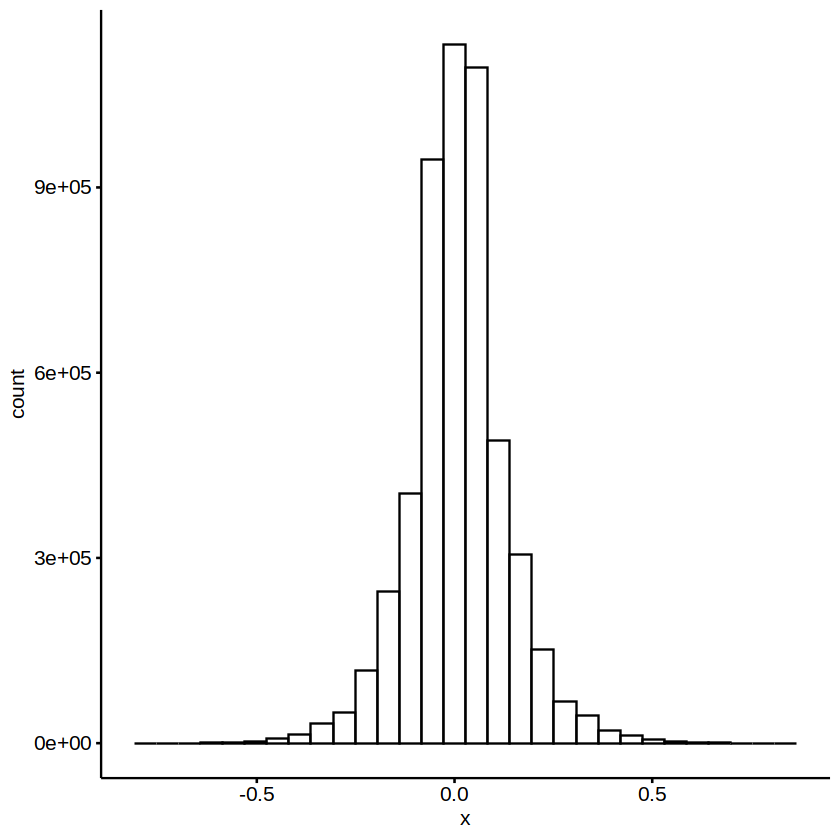

In [69]:
gghistogram(motifmatcher_chip.se$virtual_chip.dt$score)

In [158]:
motifmatcher_chip.se = readRDS(file.path(io$outdir, 'silicoChIP_cisbp.rds'))

In [237]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()

chromvar_deviations.se = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'VirtualChipScores',
                                                   background = NULL, #bgdPeaks.se,
                                                   genome = BSgenome.Mmusculus.UCSC.mm10, # Only needed if background = NULL
                                                   positive_only = TRUE, 
                                                   min_chip_score = 0.15,
                                                   min_number_peaks = 50,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = 42)
b = Sys.time()
b-a

In [207]:
saveRDS(chromvar_deviations.se, file.path(io$outdir, 'silicoChIP_cisbp_chromVAR.rds'))

In [238]:
chromvar_deviations.se

class: SummarizedExperiment 
dim: 464 16742 
metadata(0):
assays(2): deviations z
rownames(464): AHCTF1 AHR ... ZSCAN10 ZSCAN20
rowData names(2): fractionMatches fractionBackgroundOverlap
colnames(16742): LK#CAGGTGGAGACTTATG-1 LK#TCTCGCCCAGTCTAAT-1 ...
  LSK#TTGGAGGCACCACAAC-1 LSK#CCCTGTTAGCTTACTT-1
colData names(0):

In [213]:
meta3 = cbind(meta2, rna.sce@int_colData@listData$reducedDims$umap)

In [224]:
rna.sce = logNormCounts(rna.sce)

In [239]:
chromvar_deviations.se = chromvar_deviations.se[, meta3$cell_archr]

In [249]:
plot_umap = function(TF){
    tmp = meta3 %>%
        .[, gex := as.vector(logcounts(rna.sce[str_to_title(TF),]))] %>%
        .[, silicoChIP := as.vector(chromvar_deviations.se[TF,]@assays@data$z)]
    
    p1 = ggplot(tmp[order(gex)], aes(UMAP_1, UMAP_2, color = gex)) + 
        geom_point() +
        viridis::scale_color_viridis() + 
        ggtitle(paste0(TF,': Expression')) + 
        theme_void()
    
    p2 = ggplot(tmp[order(abs(silicoChIP))], aes(UMAP_1, UMAP_2, color = silicoChIP)) + 
        geom_point() +
        scale_color_gradient2(low = 'blue', mid = 'grey90', high = 'red') + 
        ggtitle('ChromVAR (silico ChIP)') + 
        theme_void()
    
    return(ggarrange(p1, p2, align = 'hv'))
}

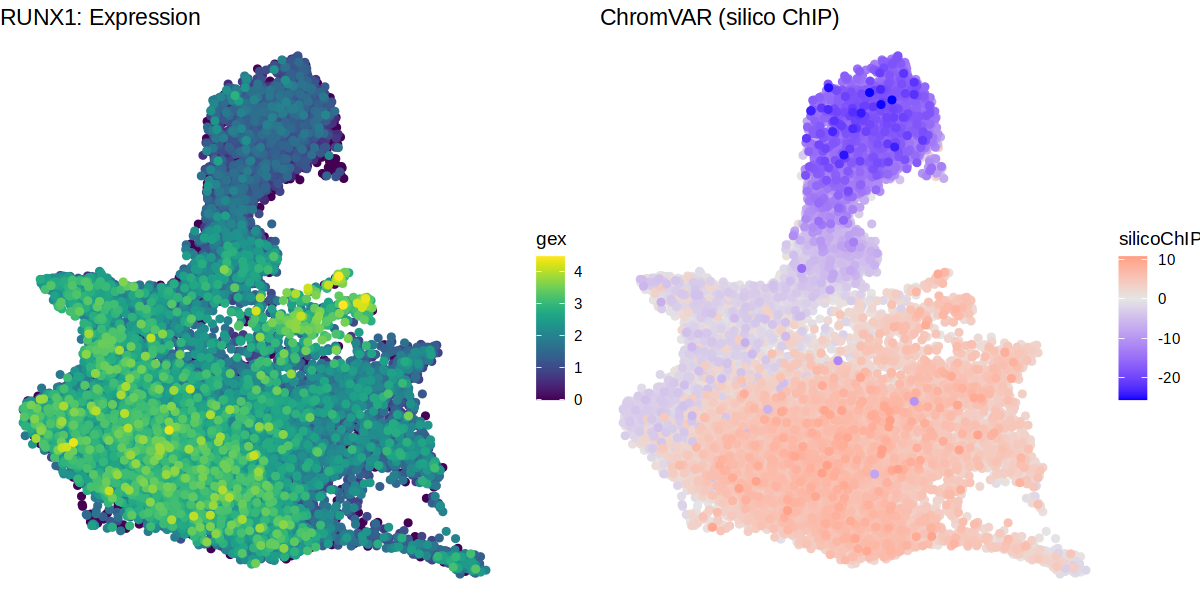

In [266]:
options(repr.plot.width = 10, repr.plot.height = 5)
plot_umap('RUNX1')

In [270]:
######################################
## ChromVAR - ChIP-seq
######################################
a = Sys.time()

chromvar_deviations.se_original = chromVAR_chip(atac.sce = atac.sce, 
                                                   motifmatcher_chip.se = motifmatcher_chip.se,
                                                   assay = 'motifScores',
                                                   background = NULL, #bgdPeaks.se,
                                                   genome = BSgenome.Mmusculus.UCSC.mm10, # Only needed if background = NULL
                                                   positive_only = FALSE, 
                                                   min_chip_score = 0,
                                                   min_number_peaks = 1,
                                                   TFs_filt = NULL,
                                                   test = FALSE,
                                                   method = 'ArchR', # Option 'ArchR' or 'ChromVAR'
                                                   cores = 42)
b = Sys.time()
b-a

[1] "Number of matches before filtering based on minimum ChIP-seq score: 5221863"
[1] "Number of matches after filtering based on minimum ChIP-seq score: 5221863"
Calculating background peaks 
Running ChromVAR-ChIP-seq (ArchR implementation) 


Time difference of 2.102066 mins

In [273]:
plot_umap = function(TF){
    tmp = meta3 %>%
        .[, gex := as.vector(logcounts(rna.sce[str_to_title(TF),]))] %>%
        .[, silicoChIP := as.vector(chromvar_deviations.se_original[TF,]@assays@data$z)]
    
    p1 = ggplot(tmp[order(gex)], aes(UMAP_1, UMAP_2, color = gex)) + 
        geom_point() +
        viridis::scale_color_viridis() + 
        ggtitle(paste0(TF,': Expression')) + 
        theme_void()
    
    p2 = ggplot(tmp[order(abs(silicoChIP))], aes(UMAP_1, UMAP_2, color = silicoChIP)) + 
        geom_point() +
        scale_color_gradient2(low = 'blue', mid = 'grey90', high = 'red') + 
        ggtitle('ChromVAR (silico ChIP)') + 
        theme_void()
    
    return(ggarrange(p1, p2, align = 'hv'))
}

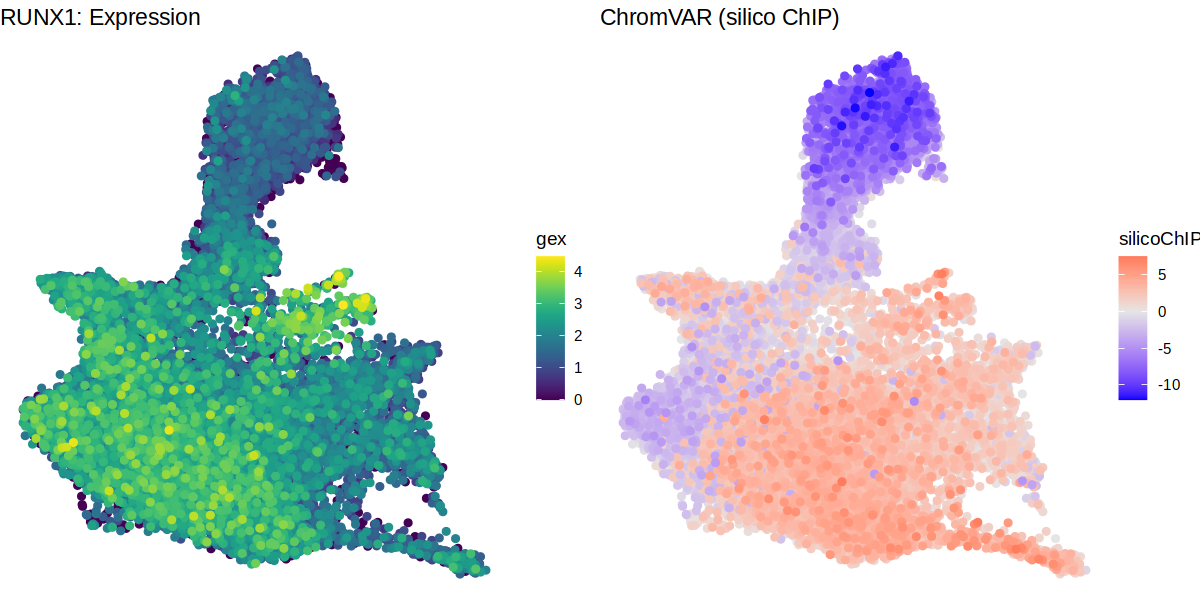

In [274]:
options(repr.plot.width = 10, repr.plot.height = 5)
plot_umap('RUNX1')

# Jaspar2020

In [55]:
JASPAR2020::JASPAR2020

An object of class "JASPAR2020"
Slot "db":
[1] "/rds/project/rds-SDzz0CATGms/users/bt392/miniconda3/envs/env_all/lib/R/library/JASPAR2020/extdata/JASPAR2020.sqlite"


In [47]:
## Get motif matches for example motifs in peaks 
## Adapted from: https://rdrr.io/github/GreenleafLab/ArchR/src/R/AnnotationPeaks.R
# Load motifs
library(motifmatchr)
library(JASPAR2020)

args <- list(species = "Homo sapiens", collection = "CORE") # Needs to be human?
motifs <- TFBSTools::getMatrixSet(JASPAR2020::JASPAR2020, args)
obj <- ArchR:::.summarizeJASPARMotifs(motifs)
motifs <- obj$motifs
motifSummary <- obj$motifSummary
#names(motifs) = gsub( 'TBXT', 'T', names(motifs)) # Rename T to fit

# Find scores
motifmatcher.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = vitroPeaks, 
                                        genome = "mm10", 
                                        out = 'scores',
                                        p.cutoff = 5e-05,
                                        w = 7) 

In [52]:
# Add peak names to objects
peaks = paste0(seqnames(vitroPeaks), ':', ranges(vitroPeaks))
rownames(atac.pb) = peaks
rownames(motifmatcher.se) = peaks

motif2gene.dt = data.table(motif = colnames(motifmatcher.se),
                           gene = toupper(str_split(colnames(motifmatcher.se), '_') %>% map_chr(1)))

In [53]:
###################
## Correlate TF-expr & Region-accessibility
###################  
a = Sys.time()
tf2peak_cor.se = cor_TF_acc(rna.sce = rna.pb, 
                          atac.sce = atac.pb, 
                          TFs_filt = NULL, #colData(motifmatcher.se)$name,  # c('SOX17', 'MYBL1') -> test runs
                          motifmatcher.se = motifmatcher.se, 
                          motif2gene.dt = motif2gene.dt,
                          correlation_method = "pearson", 
                          remove_motifs = NULL,
                          cores=6) # got an error this time with more cores
b = Sys.time()
b-a

[1] "Removing 0 TFs that have duplicated gene-motif pairs:\n"


Correlate TF-expr & Region-accessibility for 504 TFs



Time difference of 55.27338 secs

In [54]:
######################################
## Create virtual chip-seq library 
######################################
a = Sys.time()
motifmatcher_chip.se = silico_chip(atac.sce = atac.pb, 
                           tf2peak_cor.se = tf2peak_cor.se,
                           motifmatcher.se = motifmatcher.se,
                           motif2gene.dt = motif2gene.dt, 
                           min_number_peaks = 50,
                           TFs_filt = NULL, 
                           remove_motifs = NULL,
                           cores = 6)
b = Sys.time()
b-a

[1] "Number of peaks: 234908"
[1] "Predicting TF binding sites..."
[1] "Number of TFs: 504"
[1] "Updating motifmatchr results using the virtual ChIP-seq library..."


Time difference of 29.37032 secs

In [56]:
saveRDS(motifmatcher_chip.se$motifmatcher_chip.se, file.path(io$outdir, 'vitro_peaks_silicoChIP_jaspar2020.rds'))